# Clean FERM Result Graphs

This notebook does **not** run RM/FERM simulations. It only reads saved simulation artifacts and produces cleaner figures.

Workflow:
1. Run the simulation notebook up to the test evaluation.
2. Run the `Save Simulation Artifacts` cell in that notebook.
3. Come here, choose the artifact set below, and make figures.


## 0. Choose Artifact Set

Use `presentation_all_features` for the full feature-normalization comparison, or `combined_gdp_sci` for the combined GDP + SCI notebook.


In [73]:
from pathlib import Path

PREFERRED_ARTIFACT_NAME = "combined_gdp_sci"  # choices: "presentation_all_features", "combined_gdp_sci"
ARTIFACT_ROOT = Path("outputs/simulation_artifacts")
available_artifacts = sorted([p.name for p in ARTIFACT_ROOT.iterdir() if p.is_dir()]) if ARTIFACT_ROOT.exists() else []

ARTIFACT_NAME = PREFERRED_ARTIFACT_NAME
if not (ARTIFACT_ROOT / ARTIFACT_NAME).exists() and available_artifacts:
    print(f"Preferred artifact {ARTIFACT_NAME!r} not found. Using {available_artifacts[0]!r} instead.")
    ARTIFACT_NAME = available_artifacts[0]

ARTIFACT_DIR = ARTIFACT_ROOT / ARTIFACT_NAME
FIG_DIR = Path("outputs/clean_figures") / ARTIFACT_NAME
SAVE_FIGURES = True

FIG_DIR.mkdir(parents=True, exist_ok=True)
print("Available artifacts:", available_artifacts)
print("Reading artifacts from:", ARTIFACT_DIR.resolve())
print("Saving figures to:", FIG_DIR.resolve())



Available artifacts: ['combined_gdp_sci', 'presentation_all_features']
Reading artifacts from: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/simulation_artifacts/combined_gdp_sci
Saving figures to: /Users/vittoriabettio/Desktop/PhD/Research/FERM/Github/FERM_python/outputs/clean_figures/combined_gdp_sci


## 1. Imports and Loaders


In [74]:
import json
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "font.size": 11,
})


def savefig(name):
    if SAVE_FIGURES:
        path = FIG_DIR / f"{name}.png"
        plt.savefig(path, dpi=220, bbox_inches="tight")
        print("saved:", path)


def require_file(path: Path):
    if not path.exists():
        raise FileNotFoundError(
            f"Missing {path}. Run the simulation notebook and then its 'Save Simulation Artifacts' cell first."
        )
    return path


def log10p(x):
    return np.log10(np.asarray(x, dtype=float) + 1.0)


def canonical_routes(routes: pd.DataFrame) -> pd.DataFrame:
    """Make a generic long route table with pred_model/abs_log_model columns."""
    frames = []
    for model_key, g in routes.groupby("model_key", sort=False):
        g = g.copy()
        for generic, prefix in [
            ("pred_model", "pred_"),
            ("abs_log_model", "abs_log_"),
            ("abs_error_model", "abs_error_"),
            ("log_ratio_model", "log_ratio_"),
        ]:
            specific = f"{prefix}{model_key}"
            if specific in g.columns:
                g[generic] = g[specific]
            elif generic not in g.columns:
                g[generic] = np.nan
        if "observed_log10" not in g.columns:
            g["observed_log10"] = log10p(g["num_migrants"])
        if "rm_pred_log10" not in g.columns:
            g["rm_pred_log10"] = log10p(g["pred_rm"])
        if "model_pred_log10" not in g.columns:
            g["model_pred_log10"] = log10p(g["pred_model"])
        frames.append(g)
    return pd.concat(frames, ignore_index=True) if frames else routes.copy()


def metric_with_ci(df, metric):
    if {f"{metric}_ci_low", f"{metric}_ci_high"}.issubset(df.columns):
        y = df[metric].to_numpy(float)
        low = df[f"{metric}_ci_low"].to_numpy(float)
        high = df[f"{metric}_ci_high"].to_numpy(float)
        return y, np.vstack([y - low, high - y])
    return df[metric].to_numpy(float), None



## 2. Load Saved Simulation Results


In [75]:
with open(require_file(ARTIFACT_DIR / "metadata.json")) as f:
    metadata = json.load(f)

calibration = pd.read_csv(require_file(ARTIFACT_DIR / "calibration_summary.csv"))
best_by_model = pd.read_csv(require_file(ARTIFACT_DIR / "best_by_model.csv"))
test_summary = pd.read_csv(require_file(ARTIFACT_DIR / "test_summary.csv"))
calibration_routes = canonical_routes(pd.read_csv(require_file(ARTIFACT_DIR / "calibration_routes.csv.gz")))
test_routes = canonical_routes(pd.read_csv(require_file(ARTIFACT_DIR / "test_routes.csv.gz")))

sigma_diag_path = ARTIFACT_DIR / "sigma_diagnostics.csv"
sigma_diagnostics = pd.read_csv(sigma_diag_path) if sigma_diag_path.exists() else pd.DataFrame()

print("Artifact:", metadata.get("artifact_name"))
print("Models:", calibration["model"].nunique())
print("Calibration rows:", len(calibration), "| calibration route rows:", len(calibration_routes))
print("Test rows:", len(test_summary), "| test route rows:", len(test_routes))
display(test_summary.sort_values("median_improvement_abs_log", ascending=False).head(10))



/var/folders/23/tdv39nqs7c1260lvn9d3tf1r0000gn/T/ipykernel_45992/2741312490.py:7: DtypeWarning: Columns (0: transform) have mixed types. Specify dtype option on import or set low_memory=False.
  calibration_routes = canonical_routes(pd.read_csv(require_file(ARTIFACT_DIR / "calibration_routes.csv.gz")))


Artifact: combined_gdp_sci
Models: 6
Calibration rows: 50 | calibration route rows: 103500
Test rows: 7 | test route rows: 12420


,model,family,sigma,pairs,observed_total,predicted_total,MAE,RMSE,Pearson_log,Spearman_log,...,median_improvement_abs_log,mean_improvement_abs_log,share_better_abs_log,R2_log_gain_vs_RM,R2_log_model,R2_log_RM,p10_improvement_abs_log,p90_improvement_abs_log,label,alpha_gdp
0,combined_additive,combined,5.0,2070,6186048.0,6186048.0,4166.681269,17155.755482,0.705374,0.708847,...,0.094743,0.194259,0.608213,0.490070,-0.066662,-0.556732,-0.452789,0.943490,Combined FERM: GDP + SCI additive,NaN
1,combined_linear_weighted,combined,5.0,2070,6186048.0,6186048.0,4179.337920,17026.173407,0.697335,0.701528,...,0.060751,0.139317,0.568599,0.353681,-0.203051,-0.556732,-0.360926,0.742278,Combined FERM: GDP + SCI weighted linear,0.75
2,combined_euclidean,combined,8.0,2070,6186048.0,6186048.0,4181.408789,17210.160731,0.694754,0.695428,...,0.047873,0.125198,0.575845,0.318316,-0.238416,-0.556732,-0.299103,0.687641,Combined FERM: GDP + SCI signed Euclidean,NaN
3,gdp_only,traditional,8.0,2070,6186048.0,6186048.0,4269.061199,17712.094987,0.688347,0.692580,...,0.037579,0.102898,0.566184,0.259694,-0.297038,-0.556732,-0.277008,0.557129,Traditional FERM: GDP only,NaN
4,combined_additive_rescaled,combined,8.0,2070,6186048.0,6186048.0,4313.960255,17981.045725,0.695098,0.698714,...,0.037178,0.100667,0.562802,0.274933,-0.281799,-0.556732,-0.293986,0.579957,"Combined FERM: GDP + SCI additive, offdiag res...",NaN
5,sci_only,relational,5.0,2070,6186048.0,6186048.0,4291.404333,18174.497785,0.655997,0.651568,...,0.022338,0.058231,0.555072,0.178530,-0.378202,-0.556732,-0.304671,0.423595,Relational FERM: SCI only,NaN
6,rm,baseline,NaN,2070,6186048.0,6186048.0,4384.796104,18917.088907,0.645768,0.655662,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. Clean Calibration/Tuning Curves

Instead of plotting every model in one overloaded legend, choose a small set of lines. By default this shows the best model within each feature group/family.


Representative models:
- combined_additive
- combined_linear_weighted
- combined_euclidean
- combined_additive_rescaled
- gdp_only
- sci_only
saved: outputs/clean_figures/combined_gdp_sci/01_clean_calibration_tuning.png


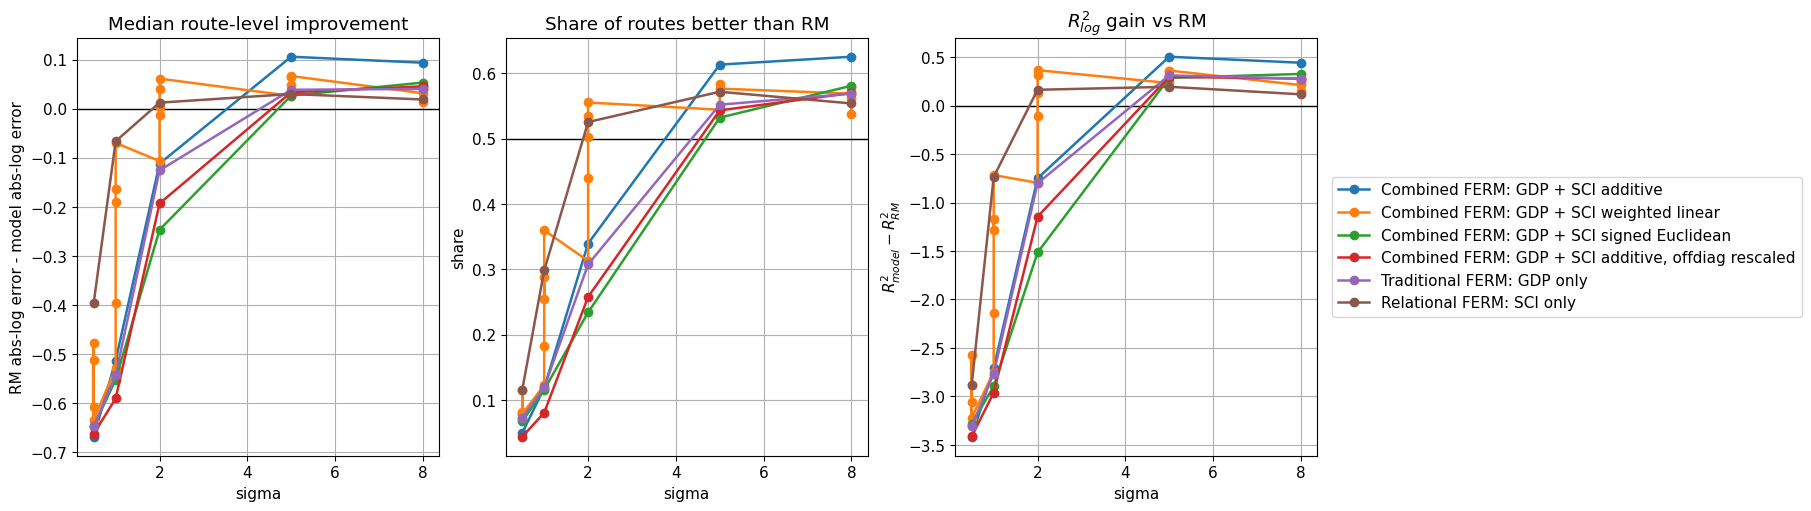

In [76]:
def choose_representative_models(calibration, best_by_model, max_models=8):
    if "feature_group" in best_by_model.columns:
        sort_cols = ["feature_group", "median_improvement_abs_log", "share_better_abs_log", "R2_log_gain_vs_RM"]
        reps = (
            best_by_model.sort_values(sort_cols, ascending=[True, False, False, False])
            .groupby("feature_group", as_index=False)
            .head(1)
        )
    else:
        reps = best_by_model.copy()
    reps = reps.sort_values("median_improvement_abs_log", ascending=False).head(max_models)
    return reps["model"].tolist()


def plot_tuning_curves(model_keys=None):
    if model_keys is None:
        model_keys = choose_representative_models(calibration, best_by_model)
    plot_df = calibration[calibration["model"].isin(model_keys)].copy()
    label_map = plot_df.drop_duplicates("model").set_index("model")["label"].to_dict() if "label" in plot_df.columns else {}

    metrics = [
        ("median_improvement_abs_log", "Median route-level improvement", "RM abs-log error - model abs-log error", 0.0),
        ("share_better_abs_log", "Share of routes better than RM", "share", 0.5),
        ("R2_log_gain_vs_RM", "$R^2_{log}$ gain vs RM", "$R^2_{model}-R^2_{RM}$", 0.0),
    ]
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    for ax, (metric, title, ylabel, ref) in zip(axes, metrics):
        for model_key in model_keys:
            g = plot_df[plot_df["model"] == model_key].sort_values("sigma")
            if g.empty:
                continue
            y, yerr = metric_with_ci(g, metric)
            ax.errorbar(g["sigma"], y, yerr=yerr, marker="o", linewidth=1.8, capsize=3, label=label_map.get(model_key, model_key))
        ax.axhline(ref, color="black", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel("sigma")
        ax.set_ylabel(ylabel)
    axes[-1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)
    savefig("01_clean_calibration_tuning")
    plt.show()

representative_models = choose_representative_models(calibration, best_by_model)
print("Representative models:")
for m in representative_models:
    print("-", m)
plot_tuning_curves(representative_models)



## 4. Test Summary: Three Metrics, Same Ordering

This is the main compact ranking figure: median improvement, share better, and $R^2_{log}$ gain.


saved: outputs/clean_figures/combined_gdp_sci/02_clean_test_summary.png


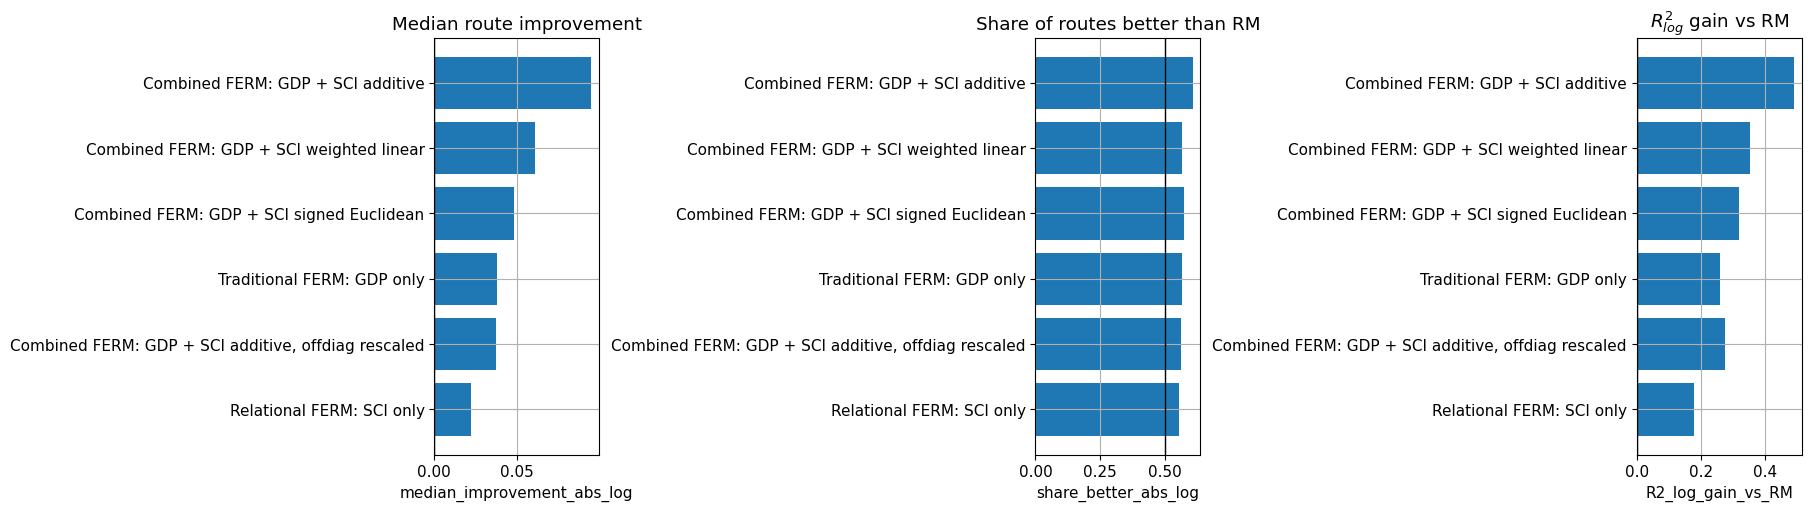

In [77]:
def plot_test_summary(top_n=10):
    df = test_summary[test_summary["model"] != "rm"].copy()
    if "R2_log_gain_vs_RM" not in df.columns and "R2_log" in df.columns:
        rm_r2 = test_summary.loc[test_summary["model"] == "rm", "R2_log"].iloc[0]
        df["R2_log_gain_vs_RM"] = df["R2_log"] - rm_r2
    df = df.sort_values("median_improvement_abs_log", ascending=False).head(top_n)
    df = df.iloc[::-1]
    labels = df["label"] if "label" in df.columns else df["model"]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    specs = [
        ("median_improvement_abs_log", "Median route improvement", 0.0),
        ("share_better_abs_log", "Share of routes better than RM", 0.5),
        ("R2_log_gain_vs_RM", "$R^2_{log}$ gain vs RM", 0.0),
    ]
    for ax, (col, title, ref) in zip(axes, specs):
        ax.barh(labels, df[col])
        ax.axvline(ref, color="black", linewidth=1)
        ax.set_title(title)
        ax.set_xlabel(col)
    savefig("02_clean_test_summary")
    plt.show()

plot_test_summary(top_n=10)



## 5. Route-Level Error Scatter, Fewer Panels

Points below the diagonal mean the model has smaller absolute log-ratio error than RM. The titles report the two most important route-level metrics.


saved: outputs/clean_figures/combined_gdp_sci/03_clean_route_error_scatter.png


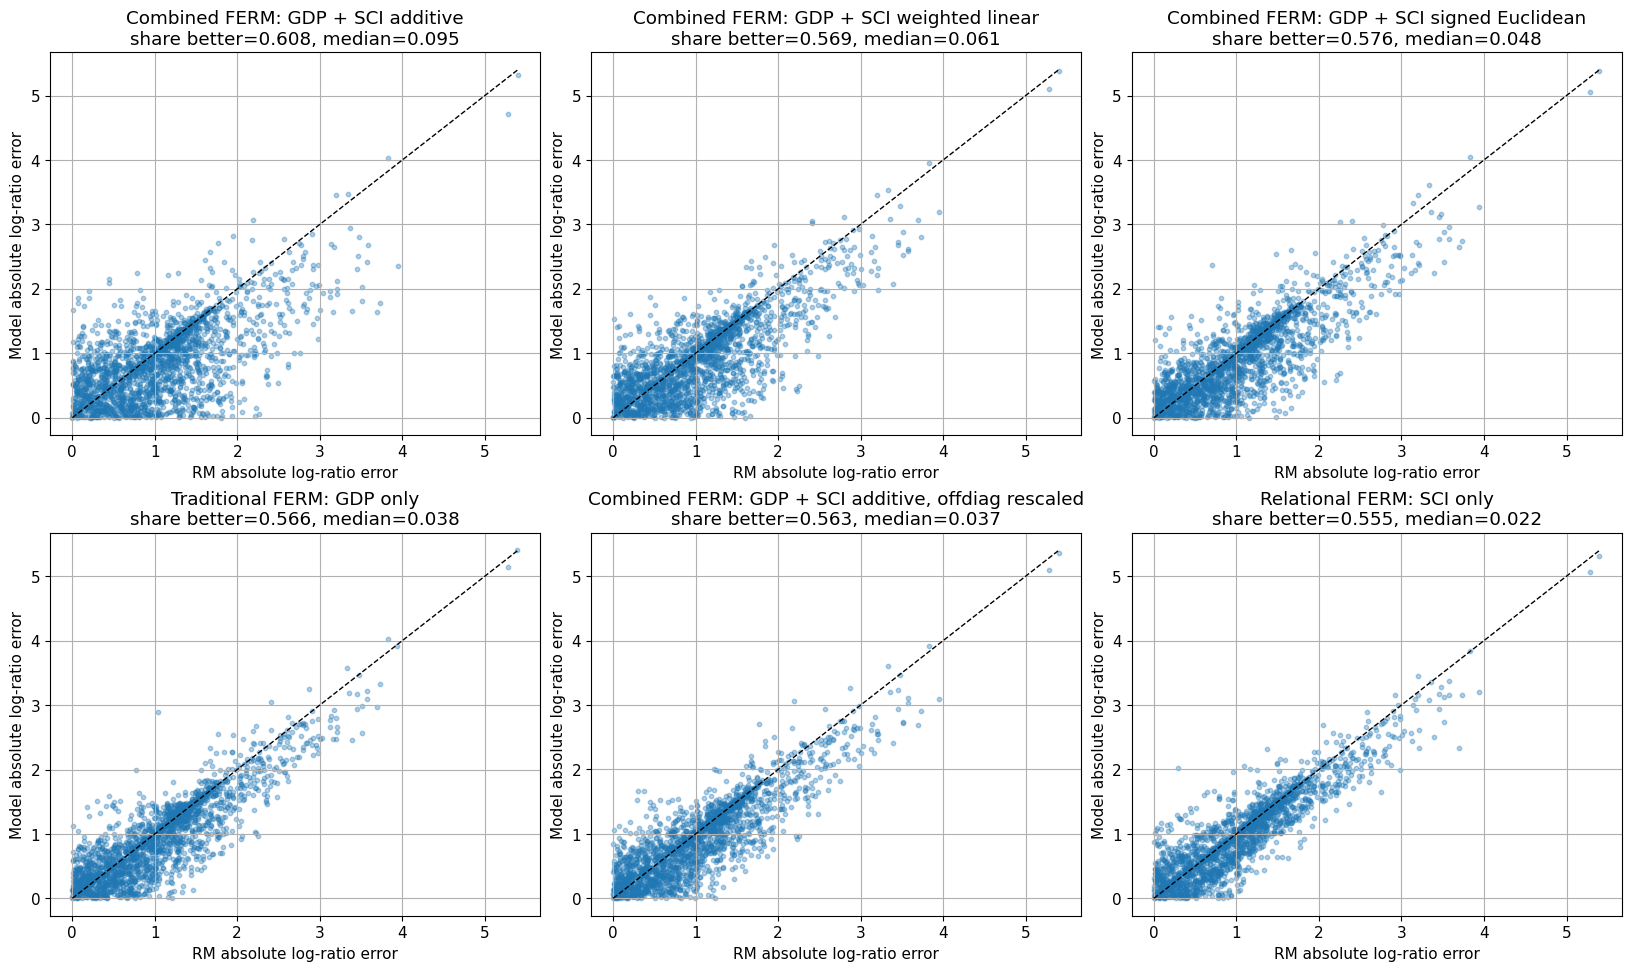

In [78]:
def plot_route_error_scatter(model_keys=None, max_models=6):
    if model_keys is None:
        model_keys = (
            test_summary[test_summary["model"] != "rm"]
            .sort_values("median_improvement_abs_log", ascending=False)
            .head(max_models)["model"]
            .tolist()
        )
    n = len(model_keys)
    ncols = min(3, n)
    nrows = math.ceil(n / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(5.4*ncols, 4.8*nrows), squeeze=False, constrained_layout=True)
    for ax, model_key in zip(axes.ravel(), model_keys):
        g = test_routes[test_routes["model_key"] == model_key].copy()
        label = g["model_label"].iloc[0] if len(g) else model_key
        ax.scatter(g["abs_log_rm"], g["abs_log_model"], s=10, alpha=0.35)
        lim = np.nanmax([g["abs_log_rm"].max(), g["abs_log_model"].max()])
        ax.plot([0, lim], [0, lim], color="black", linestyle="--", linewidth=1)
        share = (g["improvement_abs_log"] > 0).mean()
        median = g["improvement_abs_log"].median()
        ax.set_title(f"{label}\nshare better={share:.3f}, median={median:.3f}")
        ax.set_xlabel("RM absolute log-ratio error")
        ax.set_ylabel("Model absolute log-ratio error")
    for ax in axes.ravel()[n:]:
        ax.axis("off")
    savefig("03_clean_route_error_scatter")
    plt.show()

plot_route_error_scatter()



## 6. Where Models Help: Flow Size and Distance

This figure asks whether improvements concentrate on small routes, large routes, short-distance routes, or long-distance routes.


saved: outputs/clean_figures/combined_gdp_sci/04_clean_where_models_help.png


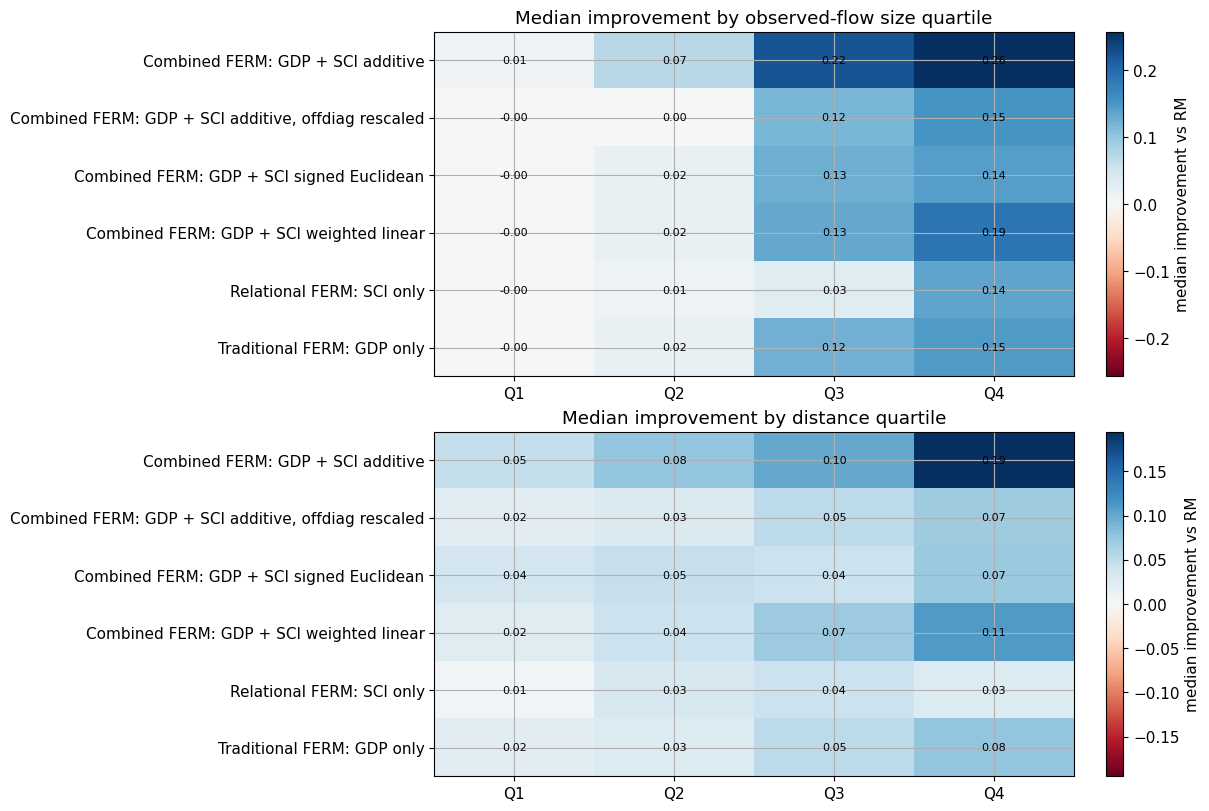

In [79]:
def binned_improvement_table(route_df, model_keys=None, by="observed", q=4):
    df = route_df.copy()
    if model_keys is not None:
        df = df[df["model_key"].isin(model_keys)].copy()
    if by == "observed":
        x = pd.Series(log10p(df["num_migrants"]), index=df.index)
        col = "observed_flow_bin"
        label = "observed-flow size"
    elif by == "distance":
        if "log10_distance" not in df.columns:
            raise ValueError("test_routes has no log10_distance column. Re-run the simulation export cell so distances are saved.")
        x = pd.to_numeric(df["log10_distance"], errors="coerce")
        col = "distance_bin"
        label = "distance"
    else:
        raise ValueError(by)

    valid = x.notna() & df["improvement_abs_log"].notna()
    df = df.loc[valid].copy()
    x = x.loc[valid]
    df[col] = pd.qcut(x.rank(method="first"), q=q, labels=False, duplicates="drop")
    pivot = df.pivot_table(index="model_label", columns=col, values="improvement_abs_log", aggfunc="median")
    return pivot, label


def plot_improvement_heatmaps(model_keys=None):
    if model_keys is None:
        model_keys = (
            test_summary[test_summary["model"] != "rm"]
            .sort_values("median_improvement_abs_log", ascending=False)
            .head(8)["model"]
            .tolist()
        )
    fig, axes = plt.subplots(2, 1, figsize=(12, 8), constrained_layout=True)
    for ax, by in zip(axes, ["observed", "distance"]):
        pivot, label = binned_improvement_table(test_routes, model_keys=model_keys, by=by)
        vmax = np.nanmax(np.abs(pivot.to_numpy()))
        im = ax.imshow(pivot.to_numpy(), aspect="auto", cmap="RdBu", vmin=-vmax, vmax=vmax)
        ax.set_title(f"Median improvement by {label} quartile")
        ax.set_yticks(range(len(pivot.index)))
        ax.set_yticklabels(pivot.index)
        ax.set_xticks(range(len(pivot.columns)))
        ax.set_xticklabels([f"Q{int(c)+1}" for c in pivot.columns])
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.iloc[i, j]
                if np.isfinite(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=8)
        fig.colorbar(im, ax=ax, label="median improvement vs RM")
    savefig("04_clean_where_models_help")
    plt.show()

plot_improvement_heatmaps()



## 7. Route Winners

For each route, this counts which model has the lowest absolute log-ratio error, including RM as a possible winner.


saved: outputs/clean_figures/combined_gdp_sci/05_clean_route_winners.png


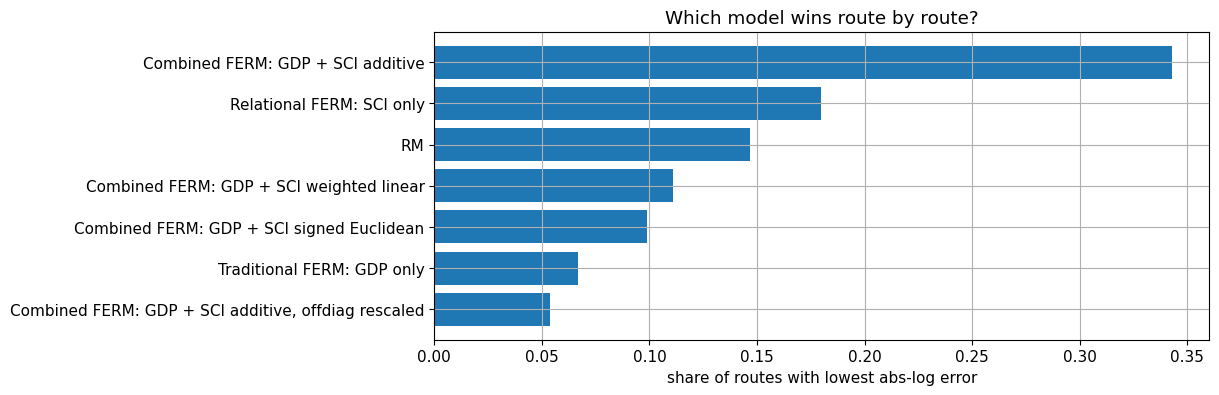

In [80]:
def winner_table(route_df):
    base_cols = ["country_from", "country_to", "country_from_name", "country_to_name", "num_migrants"]
    rm = route_df.drop_duplicates(["country_from", "country_to"])[base_cols + ["abs_log_rm"]].copy()
    rm["candidate"] = "RM"
    rm["candidate_key"] = "rm"
    rm["abs_log_error"] = rm["abs_log_rm"]
    frames = [rm[base_cols + ["candidate", "candidate_key", "abs_log_error"]]]
    for model_key, g in route_df.groupby("model_key"):
        label = g["model_label"].iloc[0]
        tmp = g[base_cols + ["abs_log_model"]].copy()
        tmp["candidate"] = label
        tmp["candidate_key"] = model_key
        tmp["abs_log_error"] = tmp["abs_log_model"]
        frames.append(tmp[base_cols + ["candidate", "candidate_key", "abs_log_error"]])
    long = pd.concat(frames, ignore_index=True)
    idx = long.groupby(["country_from", "country_to"])["abs_log_error"].idxmin()
    return long.loc[idx].reset_index(drop=True)

winners = winner_table(test_routes)
win_share = winners["candidate"].value_counts(normalize=True).sort_values()
fig, ax = plt.subplots(figsize=(10, max(4, 0.35*len(win_share))))
ax.barh(win_share.index, win_share.values)
ax.set_title("Which model wins route by route?")
ax.set_xlabel("share of routes with lowest abs-log error")
savefig("05_clean_route_winners")
plt.show()



## 8. Prediction Shifts Relative to RM

This shows whether each model mostly increases or decreases RM predictions, and by how much in log10 scale.


saved: outputs/clean_figures/combined_gdp_sci/06_clean_prediction_shifts.png


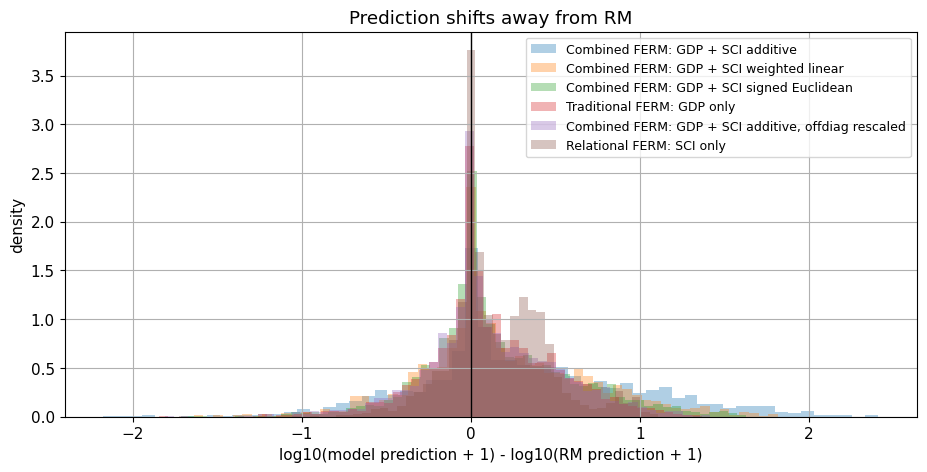

In [81]:
def plot_prediction_shift_hist(model_keys=None):
    if model_keys is None:
        model_keys = (
            test_summary[test_summary["model"] != "rm"]
            .sort_values("median_improvement_abs_log", ascending=False)
            .head(6)["model"]
            .tolist()
        )
    fig, ax = plt.subplots(figsize=(11, 5))
    for model_key in model_keys:
        g = test_routes[test_routes["model_key"] == model_key]
        label = g["model_label"].iloc[0] if len(g) else model_key
        ax.hist(g["log_shift_vs_rm"], bins=60, alpha=0.35, density=True, label=label)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title("Prediction shifts away from RM")
    ax.set_xlabel("log10(model prediction + 1) - log10(RM prediction + 1)")
    ax.set_ylabel("density")
    ax.legend(loc="best", fontsize=9)
    savefig("06_clean_prediction_shifts")
    plt.show()

plot_prediction_shift_hist()



## 9. Optional: Gaskin-Abel External Benchmark

This is only available for the combined GDP + SCI workflow if the benchmark summary has already been created.


saved: outputs/clean_figures/combined_gdp_sci/07_clean_gaskin_abel_benchmark.png


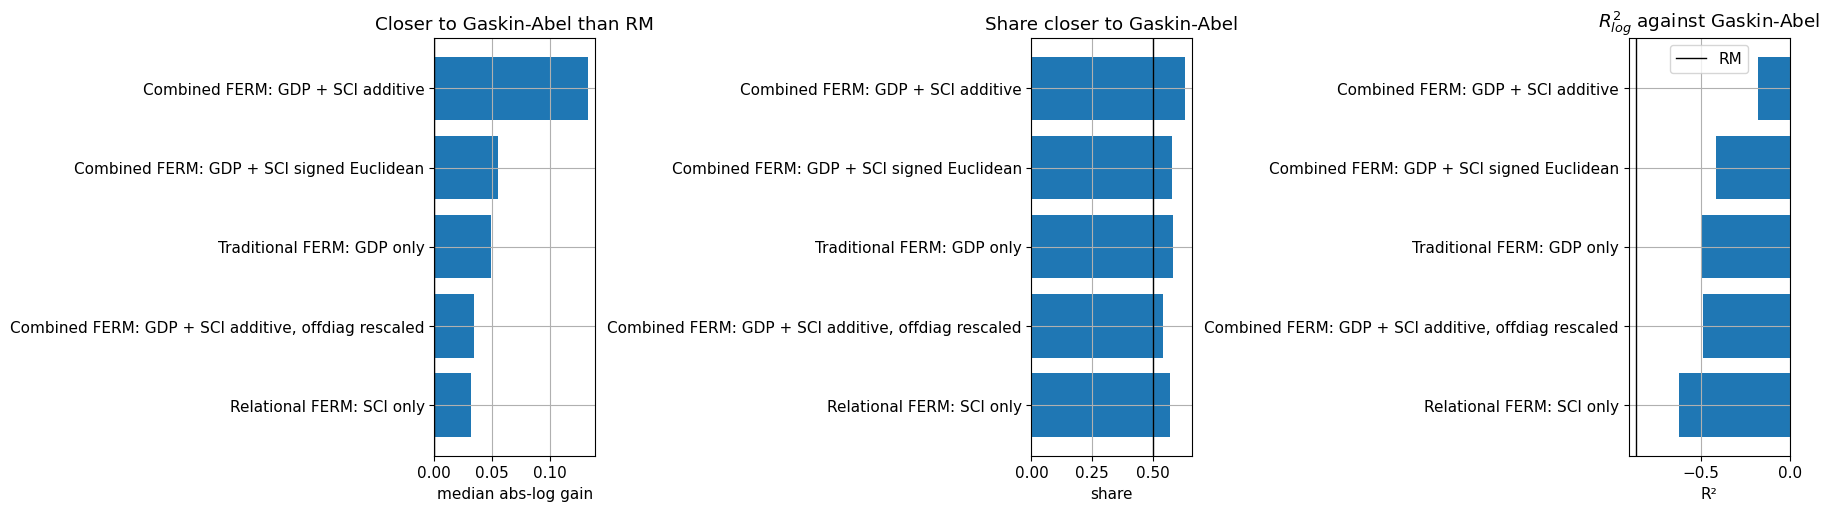

In [82]:
ga_path = Path("outputs/combined_gdp_sci_figures/06a_gaskin_abel_benchmark_summary.csv")
if ga_path.exists():
    ga = pd.read_csv(ga_path).sort_values("median_gain_vs_RM_to_GA")
    fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
    axes[0].barh(ga["label"], ga["median_gain_vs_RM_to_GA"])
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title("Closer to Gaskin-Abel than RM")
    axes[0].set_xlabel("median abs-log gain")
    axes[1].barh(ga["label"], ga["share_closer_to_GA_than_RM"])
    axes[1].axvline(0.5, color="black", linewidth=1)
    axes[1].set_title("Share closer to Gaskin-Abel")
    axes[1].set_xlabel("share")
    axes[2].barh(ga["label"], ga["R2_log_to_GA"])
    axes[2].axvline(ga["R2_log_RM_to_GA"].iloc[0], color="black", linewidth=1, label="RM")
    axes[2].set_title("$R^2_{log}$ against Gaskin-Abel")
    axes[2].set_xlabel("R²")
    axes[2].legend()
    savefig("07_clean_gaskin_abel_benchmark")
    plt.show()
else:
    print("No Gaskin-Abel benchmark summary found; skipping.")

